### Workshop “Databricks: Más Allá del Big Data”.

Aquí recorremos juntos los **4 niveles de madurez en IA**, aterrizados en un caso real de salud, integrando datos sintéticos, fuentes reales, APIs y técnicas modernas de IA generativa (RAG, batch, tuning, compliance).


### Fase 0 - Setup Inicial, Data Real/Sintética, y APIs

Antes de adentrarnos en IA, preparamos:
- **Lectura de datos reales** de Databricks (`claims_sample_synthetic`)
- **Generación de datos sintéticos avanzados** (con historias clínicas, prompts para pruebas de RAG, riesgos, etc.)
- **Conexión a APIs externas** para enriquecer la data (calidad del aire, condiciones de salud, peso/nutrición, y ratios de cáncer por estado)

Esto nos permitirá trabajar con información estructurada, semi-estructurada y contextual – exactamente como hacen los sistemas empresariales modernos.


¿Qué hacemos aquí?
Instalamos todas las librerias que vamos a usar en el notebook, despues reiniciamos python para completar las instalaciones de las mismas

In [0]:
%pip install transformers
%pip install sentence-transformers
%pip install torch
%pip install faiss-cpu
%pip install datasets
%pip install transformers[torch]
%pip install pandas
%pip install numpy
%pip install faker
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may ne

In [0]:
%restart_python

¿Qué hacemos aquí?
Importamos datos reales simulados del catálogo Databricks Serverless, para usarlos como baseline y comparar con nuestros datos sintéticos y enriquecidos.

In [0]:
df_real = spark.table("samples.healthverity.claims_sample_synthetic")
display(df_real.limit(5))

hvid,claim_id,claim_type,date_service,diagnosis_code,procedure_code,patient_gender,patient_year_of_birth,patient_zip3,patient_state,inst_admit_type_std_id,inst_admit_source_std_id,inst_discharge_status_std_id,inst_type_of_bill_std_id,inst_drg_std_id,place_of_service_std_id,service_line_number,diagnosis_code_qual,admit_diagnosis_ind,procedure_code_qual,procedure_units_billed,procedure_modifier_1,procedure_modifier_2,procedure_modifier_3,procedure_modifier_4,revenue_code,line_charge,line_allowed,prov_rendering_npi,prov_billing_npi,prov_referring_npi,payer_type,prov_rendering_std_taxonomy,prov_billing_std_taxonomy,prov_referring_std_taxonomy
984,1548910064,P,2021-04-10,F1020,null,M,1954,616,IL,null,null,null,null,null,55,null,02,N,null,null,null,null,null,null,null,null,null,1791716745,1791716745,null,MEDICAID,101YA0400X,101YA0400X,null
986,2022344325,P,2021-03-06,F32A,null,F,1982,761,TX,null,null,null,null,null,50,null,02,N,null,null,null,null,null,null,null,null,null,8163843404,3245023130,null,COMMERCIAL,363LF0000X,261QF0400X,null
986,1025201761,P,2021-08-22,E119,null,F,1982,761,TX,null,null,null,null,null,11,null,02,N,null,null,null,null,null,null,null,null,null,1761846766,1761846766,1761846766,MEDICAID,207R00000X,207R00000X,207R00000X
993,1586440609,P,2020-03-13,F410,null,F,1953,191,PA,null,null,null,null,null,11,null,02,N,null,null,null,null,null,null,null,null,null,8242446039,8242446039,null,MEDICAID,207Q00000X,207Q00000X,null
993,905241164,P,2020-05-18,K219,null,F,1953,191,PA,null,null,null,null,null,11,null,02,N,null,null,null,null,null,null,null,null,null,8242446039,8242446039,null,MEDICAID,207Q00000X,207Q00000X,null


¿Qué hacemos aquí?
Creamos un dataset sintético, más completo que el real, incluyendo:

Campos demográficos, médicos, económicos y de historia clínica (texto libre)
Campos útiles para pruebas de IA generativa/RAG, como notas clínicas, riesgos, recomendaciones, etc. Así, podemos simular escenarios de análisis, búsqueda y generación, incluso si no tenemos acceso a todos los datos reales.

In [0]:
import pandas as pd
import random
import numpy as np
from faker import Faker

fake = Faker()
n = 150
states = ['CA','TX','FL','NY','PA','IL','OH','GA','NC','MI']
diagnoses = ['Diabetes Mellitus','Essential Hypertension','Chronic Obstructive Pulmonary Disease','Asthma','Breast Cancer','Prostate Cancer','Coronary Heart Disease','Stroke','Obesity','Depression']
icd10 = ['E11','I10','J44','J45','C50','C61','I25','I63','E66','F33']
chronic_conditions = [['hypertension','obesity'],['type 2 diabetes'],['asthma'],['chronic kidney disease'],['none']]
medications = [['Metformin','Lisinopril'],['Albuterol'],['Atorvastatin','Insulin'],['Sertraline'],['none']]
vital_signs = [['BP:140/90','HR:88'],['BP:120/80','HR:70'],['BP:150/95','HR:92']]
recent_events = [['hospitalization for infection'],['ER visit for chest pain'],['routine check-up'],['none']]

def generate_medical_note(diagnosis, chronic_conditions, medications, vital_signs, recent_events):
    return (
        f"Patient presents with {diagnosis}. "
        f"Chronic conditions: {', '.join(chronic_conditions)}. "
        f"Medications: {', '.join(medications)}. "
        f"Vitals: {', '.join(vital_signs)}. "
        f"Events: {', '.join(recent_events)}. "
        f"Recommended follow-up: Annual checkup for {diagnosis}."
    )

data = []
for i in range(n):
    name = fake.name()
    patient_id = fake.unique.uuid4()
    age = random.randint(18, 90)
    gender = random.choice(['M', 'F'])
    state = random.choice(states)
    zip3 = fake.zipcode()[0:3]
    diag_idx = random.randint(0, len(diagnoses)-1)
    diagnosis = diagnoses[diag_idx]
    icd_code = icd10[diag_idx]
    conds = random.choice(chronic_conditions)
    meds = random.choice(medications)
    vitals = random.choice(vital_signs)
    events = random.choice(recent_events)
    note = generate_medical_note(diagnosis, conds, meds, vitals, events)
    claim_amount = round(random.uniform(1000, 90000), 2)
    claim_status = random.choice(['Approved', 'Rejected', 'Pending'])
    claim_date = fake.date_between(start_date='-3y', end_date='today')
    member_since = fake.date_between(start_date='-10y', end_date='-3y')
    risk_score = round(np.clip(random.gauss(0.5, 0.2), 0, 1), 2)
    data.append({
        "patient_id": patient_id,
        "name": name,
        "age": age,
        "gender": gender,
        "patient_state": state,
        "patient_zip3": zip3,
        "diagnosis": diagnosis,
        "icd10_code": icd_code,
        "clinical_notes": note,
        "claim_amount_usd": claim_amount,
        "claim_status": claim_status,
        "claim_date": claim_date,
        "member_since": member_since,
        "risk_score": risk_score
    })

df_synth_adv = pd.DataFrame(data)
df_synth_adv.to_csv("synth_health_claims_adv.csv", index=False)
print("Data sintética creada. Archivo descargable desde el panel izquierdo (Files).")


Data sintética creada. Archivo descargable desde el panel izquierdo (Files).


In [0]:
# Leer el csv en Spark
df = pd.read_csv("synth_health_claims_adv.csv")
df_spark = spark.createDataFrame(df)
display(df_spark.limit(5))

patient_id,name,age,gender,patient_state,patient_zip3,diagnosis,icd10_code,clinical_notes,claim_amount_usd,claim_status,claim_date,member_since,risk_score
0ab3f054-1f30-4b29-b7f1-5592cdce70a1,Dakota Farrell,29,M,CA,228,Diabetes Mellitus,E11,"Patient presents with Diabetes Mellitus. Chronic conditions: asthma. Medications: Sertraline. Vitals: BP:120/80, HR:70. Events: routine check-up. Recommended follow-up: Annual checkup for Diabetes Mellitus.",79677.41,Pending,2024-08-12,2017-03-10,0.1
13a1f505-8943-40db-bb52-b140f7f90dd9,Abigail Tate,21,F,OH,761,Prostate Cancer,C61,"Patient presents with Prostate Cancer. Chronic conditions: none. Medications: Sertraline. Vitals: BP:140/90, HR:88. Events: routine check-up. Recommended follow-up: Annual checkup for Prostate Cancer.",41790.02,Approved,2023-10-28,2017-02-10,0.51
92d19fee-d6db-4bcb-a7f3-66b5b95eba24,Levi Stein,71,F,CA,819,Asthma,J45,"Patient presents with Asthma. Chronic conditions: chronic kidney disease. Medications: Albuterol. Vitals: BP:150/95, HR:92. Events: ER visit for chest pain. Recommended follow-up: Annual checkup for Asthma.",80473.81,Approved,2022-12-10,2018-12-21,0.34
ddf0ec83-9cac-4c07-87c7-857c40fc71bf,Randy Baker,90,F,TX,518,Obesity,E66,"Patient presents with Obesity. Chronic conditions: hypertension, obesity. Medications: Sertraline. Vitals: BP:120/80, HR:70. Events: routine check-up. Recommended follow-up: Annual checkup for Obesity.",47033.17,Pending,2025-04-13,2016-01-11,0.35
6a40b1b8-8e17-4dfe-9ad5-5a8b79b4210e,Victoria Hinton,37,F,NC,657,Essential Hypertension,I10,"Patient presents with Essential Hypertension. Chronic conditions: none. Medications: Metformin, Lisinopril. Vitals: BP:150/95, HR:92. Events: hospitalization for infection. Recommended follow-up: Annual checkup for Essential Hypertension.",69299.88,Approved,2023-04-08,2021-11-26,0.59


> **¿Qué hacemos aquí?**
> Integramos información de APIs externas de salud y ambiente para enriquecer los registros de pacientes.
> Así, cada análisis o recomendación que hagamos puede tener en cuenta contexto real (ej: calidad del aire, ratio de cáncer, factores ambientales o epidemiológicos).
> Esto es clave en sistemas IA modernos, donde el contexto externo es tan relevante como el dato estructurado.


In [0]:
import requests

# --- API Key: pon aquí tu RapidAPI Key personal, la de Sebastian debes removerla
RAPIDAPI_KEY = "2b9d8bf1eemshecf5ae56a4d018bp15995cjsn75bc174fb117"  # Usa la tuya

state_to_city = {
    "CA": "Los Angeles",
    "TX": "Houston",
    "FL": "Miami",
    "NY": "New York",
    "PA": "Philadelphia",
    "IL": "Chicago",
    "OH": "Columbus",
    "GA": "Atlanta",
    "NC": "Charlotte",
    "MI": "Detroit"
}
def get_air_quality(state):
    city = state_to_city.get(state, None)
    if not city:
        return None
    url = "https://airvisual1.p.rapidapi.com/v2/city"
    headers = {
        "x-rapidapi-host": "airvisual1.p.rapidapi.com",
        "x-rapidapi-key": RAPIDAPI_KEY
    }
    params = {
        "city": city,
        "state": state,
        "country": "USA"
    }
    try:
        response = requests.get(url, headers=headers, params=params, timeout=10)
        data = response.json()
        aqi = data['data']['current']['pollution']['aqius'] if "data" in data and "current" in data["data"] else None
        return aqi
    except Exception as e:
        print(f"Error AQI {state}: {e}")
        return None

def get_cancer_rate(state):
    url = f"https://cancer-rates-by-usa-state.p.rapidapi.com/YDaHXO/cancer_rates_by_usa_state?State={state}"
    headers = {
        "x-rapidapi-host": "cancer-rates-by-usa-state.p.rapidapi.com",
        "x-rapidapi-key": RAPIDAPI_KEY
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        data = response.json()
        if isinstance(data, list) and data:
            return data[0].get("Range", None)
        elif isinstance(data, dict) and "message" in data:
            return data["message"]
        else:
            return None
    except Exception as e:
        print(f"Error Cancer Rate {state}: {e}")
        return None

def get_ww_points(calories, sugar, protein, sat_fat):
    url = "https://health-calculator-api.p.rapidapi.com/weight-watchers-points"
    headers = {
        "content-type": "application/json",
        "x-rapidapi-host": "health-calculator-api.p.rapidapi.com",
        "x-rapidapi-key": RAPIDAPI_KEY
    }
    payload = {
        "calories": calories,
        "sugar": sugar,
        "protein": protein,
        "saturated_fat": sat_fat
    }
    try:
        response = requests.post(url, json=payload, headers=headers, timeout=10)
        data = response.json()
        if isinstance(data, dict) and 'weight_watchers_smart_points' in data:
            return data['weight_watchers_smart_points']
        return None
    except Exception as e:
        print(f"Error WW Points: {e}")
        return None

row = df_synth_adv.iloc[0]
state = row['patient_state']

print(f"\nBuscando AQI y Cancer Rate para: {state}")

aqi = get_air_quality(state)
print("AQI:", aqi)

cancer_rate = get_cancer_rate(state)
print("Cancer Rate:", cancer_rate)

# Demo de WW Points (puedes ajustar valores reales si los tienes)
calories, sugar, protein, sat_fat = 500, 10, 20, 5
ww_points = get_ww_points(calories, sugar, protein, sat_fat)
print("Weight Watchers Points:", ww_points)

# --- Si quieres agregar estos datos al DataFrame ---
df_synth_adv.loc[0, "aqi"] = aqi
df_synth_adv.loc[0, "cancer_rate"] = cancer_rate
df_synth_adv.loc[0, "ww_points"] = ww_points

print("\nFila enriquecida:")
print(df_synth_adv.head(1)[["patient_state", "aqi", "cancer_rate", "ww_points"]])


Buscando AQI y Cancer Rate para: CA
AQI: None
Cancer Rate: 127.9 to 155.3
Weight Watchers Points: 15.86

Fila enriquecida:
  patient_state  aqi     cancer_rate  ww_points
0            CA  NaN  127.9 to 155.3      15.86


---
## Fase 1 - Usar la IA: Prompt Engineering, LLM APIs, y experimentación de parámetros

**¿Qué estamos haciendo?**  
- Probamos prompts médicos realistas sobre notas clínicas sintéticas, usando modelos HuggingFace/OpenAI.
- Variamos parámetros como temperatura, top_p y top_k para ver cómo cambia el output.
- Mostramos cómo APIs y prompts se combinan en sistemas productivos modernos (ejemplo: sumar contexto de calidad de aire o ratio de cáncer al prompt).
---


> En este bloque, tomamos una nota clínica sintética y creamos un prompt realista para un LLM.  
> Además, incluimos información contextual (como riesgo ambiental) en el prompt, para simular cómo los sistemas RAG generan respuestas “context-aware”.


In [0]:
from transformers import pipeline

row = df_synth_adv.iloc[0]
context = row['clinical_notes']
cancer = get_cancer_rate(row['patient_state'])
cancer_str = str(cancer)
prompt = f"Patient state: {row['patient_state']}. Cancer stats: {cancer_str}. Clinical note: {context}\n\nQuestion: What preventive recommendations would you suggest as an AI medical assistant?"
summarizer = pipeline("text-generation", model="gpt2")
output = summarizer(prompt, max_length=120, temperature=0.7)[0]['generated_text']
print(output)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0xff941a920400>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.12/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
De

Patient state: CA. Cancer stats: 127.9 to 155.3. Clinical note: Patient presents with Diabetes Mellitus. Chronic conditions: asthma. Medications: Sertraline. Vitals: BP:120/80, HR:70. Events: routine check-up. Recommended follow-up: Annual checkup for Diabetes Mellitus.

Question: What preventive recommendations would you suggest as an AI medical assistant?

Answer: Some of my favorite things were the way it came down to me and where I think it is best to go in my current situation. I think that there are a lot of things that are wrong with the current system, that need to be resolved in a way that is a better fit for our current situation. But I don't think that there is any particular right way to do it.

I would not suggest any of these things. I think there are a lot of things that need to be done, and I think they need to be done for the right reasons. I think there's a lot of things that need to be done. And there's a lot of things that need to be done. And the fact that we don't


Estamos utilizando un modelo base de lenguaje natural, por lo que los resultados pueden contener texto repetitivo o poco relevante. Para producción, recomendamos migrar a un modelo entrenado para tareas clínicas o de preguntas-respuestas, para asegurar precisión y valor en la información generada

%md
> En este bloque,adicional a lo que mencionamos anteriormente esta usando **flan-T5** que nos respuestas mucho mas útiles y directas ya que es un modelo optimizado para seguir instrucciones, responder preguntas y resumir bien.  
> Además, incluimos información contextual (como riesgo ambiental) en el prompt, para simular cómo los sistemas RAG generan respuestas “context-aware”.

In [0]:
from transformers import pipeline

row = df_synth_adv.iloc[0]
context = row['clinical_notes']
cancer = get_cancer_rate(row['patient_state'])
cancer_str = str(cancer)

# Prepara un prompt estilo instructivo
prompt = (
    f"Context: {context}\n"
    f"Cancer stats: {cancer_str}\n"
    f"Question: What preventive medical recommendations would you give for this patient? Answer in 2 sentences, practical and concrete."
)
# Usa el modelo FLAN-T5-LARGE
generator = pipeline("text2text-generation", model="google/flan-t5-large")
output = generator(prompt, max_length=80)[0]['generated_text']
print("FLAN-T5 Response:", output)


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FLAN-T5 Response: Annual checkup for Diabetes Mellitus.


%md
> En este bloque, usamos Zephyr que es mucho mas robusto y se acerca mucho mas a un modelo generativo. se recomienda usar si tienes acceso a GPU y computo robusto
> Además, incluimos información contextual (como riesgo ambiental) en el prompt, para simular cómo los sistemas RAG generan respuestas “context-aware”.

In [0]:
from transformers import pipeline

row = df_synth_adv.iloc[0]
context = row['clinical_notes']
cancer = get_cancer_rate(row['patient_state'])
cancer_str = str(cancer)
# prompt instructivo, aún mejor si usas ### como delimitador (Zephyr lo entiende mejor)
prompt = (
    f"### Context:\n{context}\n"
    f"### Cancer stats: {cancer_str}\n"
    f"### Question:\nWhat preventive medical recommendations would you give for this patient? Be clear and concise."
)
# Usamos el modelo Zephyr-7B
generator = pipeline("text-generation", model="HuggingFaceH4/zephyr-7b-beta")
output = generator(prompt, max_length=80, temperature=0.7)[0]['generated_text']
print("Zephyr Response:", output)


config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

model-00006-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00007-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

---
## Fase 2 - Integrar la IA: RAG (Retrieval Augmented Generation), Embeddings y Búsquedas Semánticas

**¿Qué estamos haciendo?**  
- Generamos embeddings a partir de notas clínicas (texto libre) para permitir búsquedas semánticas, agrupación de pacientes similares y RAG.
- Integramos datos estructurados (ej: ratios de cáncer, calidad del aire) como “contexto recuperado”.
- Probamos búsqueda por similaridad y generación de recomendaciones personalizadas basadas en el contexto recuperado.

Esta fase es la base de los sistemas de IA modernos en salud y enterprise:  
“**La IA ya no solo predice: ahora responde usando todos tus datos + contexto externo.**”
---


> Aquí generamos embeddings, hacemos una búsqueda semántica (¿qué pacientes se parecen a este caso?) y generamos una respuesta personalizada basada en el contexto recuperado.


In [0]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')
texts = df_synth_adv['clinical_notes'].tolist()
embeddings = model.encode(texts)

query = "Patient with history of diabetes and ER visits"
query_vec = model.encode([query])
similarities = np.dot(embeddings, query_vec[0])
top_idx = np.argsort(similarities)[::-1][:3]
for idx in top_idx:
    print(f"Paciente similar: {df_synth_adv.iloc[idx]['name']} | {df_synth_adv.iloc[idx]['clinical_notes']}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Paciente similar: Jennifer Douglas | Patient presents with Diabetes Mellitus. Chronic conditions: none. Medications: Albuterol. Vitals: BP:140/90, HR:88. Events: hospitalization for infection. Recommended follow-up: Annual checkup for Diabetes Mellitus.
Paciente similar: Kara Johnson | Patient presents with Diabetes Mellitus. Chronic conditions: hypertension, obesity. Medications: Albuterol. Vitals: BP:120/80, HR:70. Events: ER visit for chest pain. Recommended follow-up: Annual checkup for Diabetes Mellitus.
Paciente similar: Troy Yates | Patient presents with Diabetes Mellitus. Chronic conditions: hypertension, obesity. Medications: Albuterol. Vitals: BP:120/80, HR:70. Events: ER visit for chest pain. Recommended follow-up: Annual checkup for Diabetes Mellitus.


> Mini-RAG: Ahora usamos la nota más similar + contexto API para hacer un prompt generativo.

In [0]:
from transformers import pipeline

# Selecciona la fila y contexto
row = df_synth_adv.iloc[top_idx[0]]
context = row['clinical_notes']
cancer = get_cancer_rate(row['patient_state'])
cancer_str = str(cancer)
# Preparamos el prompt de forma instructiva (en inglés porque el modelo está entrenado así)
prompt = (
    f"Context: {context}\n"
    f"Cancer stats: {cancer_str}\n"
    f"Question: What preventive medical recommendations would you give for this patient? "
    f"Answer in 2 clear and specific sentences."
)
# Usamos otravez FLAN-T5 (el Large es rápido y bueno)
generator = pipeline("text2text-generation", model="google/flan-t5-large")
output = generator(prompt, max_length=80)[0]['generated_text']
print("\nRespuesta FLAN-T5:")
print(output)


Device set to use cpu
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Respuesta FLAN-T5:
Annual checkup for Diabetes Mellitus. Cancer stats: 127.9 to 155.3


# 5. Fase 3: Sistemas IA (Fine/Instruction Tuning, Compliance)

---
## Fase 3 - Sistemas IA: Fine Tuning, Instruction Tuning y Evaluación de Modelos

**¿Qué estamos haciendo?**  
- Mostramos cómo ajustar un modelo de lenguaje (fine tuning) para tareas clínicas específicas (ejemplo: clasificación de riesgo, compliance, etc.)
- Usamos nuestro dataset sintético (y si quieres, algunos ejemplos reales) para entrenamiento rápido.
- Explicamos la importancia de la evaluación y compliance (accuracy, F1, auditoría de outputs).

Esto es lo que separa el uso casual de IA del despliegue profesional:  
**Customización, ajuste, monitoreo y control.**
---


> En este bloque, entrenamos rápidamente un modelo base para identificar pacientes con “diabetes” en su historia, y evaluamos su precisión.  
> Esta práctica es la base de la medicina personalizada y de los sistemas clínicos modernos.


In [0]:
import pandas as pd
from datasets import Dataset
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, AutoTokenizer

df_pd = pd.read_csv("/Workspace/Users/datadevforge@gmail.com/techsphere-workspace/synth_health_claims_adv.csv")
# Subset PEQUEÑO para demo rápida
texts = df_pd['clinical_notes'].astype(str).tolist()[:50]
labels = [1 if "diabetes" in t.lower() else 0 for t in texts]
dataset = Dataset.from_dict({"text": texts, "label": labels})

# Tokenizer y modelo
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=48)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    save_strategy="no",
    logging_strategy="no"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets
)
trainer.train()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

/local_disk0/.ephemeral_nfs/envs/pythonEnv-33ccecd9-c3a3-4f17-a7e8-b8a4c2deda23/lib/python3.12/site-packages/accelerate/state.py:271: UserWarning: OMP_NUM_THREADS/MKL_NUM_THREADS unset, we set it at 4 to improve oob performance.
  warnings.warn(
[E926 20:02:08.172705762 socket.cpp:1019] [c10d] The client socket has timed out after 1800000ms while trying to connect to (localhost, 57703).
[W926 20:02:08.190350621 TCPStore.cpp:340] [c10d] TCP client failed to connect/validate to host localhost:57703 - retrying (try=0, timeout=1800000ms, delay=81504ms): The client socket has timed out after 1800000ms while trying to connect to (localhost, 57703).
Exception raised from throwTimeoutError at /pytorch/torch/csrc/distributed/c10d/socket.cpp:1021 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0xb0 (0xffdcf07148c0 in /local_disk0/.ephemeral_nfs/envs/pythonEnv-33ccecd9-c3a3-4f17-a7e8-b8a4

---------------------------------------------------------------------------
DistNetworkError                          Traceback (most recent call last)
File <command-4578307449125159>, line 20
     16     return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=48)
     18 tokenized_datasets = dataset.map(tokenize_function, batched=True)
---> 20 training_args = TrainingArguments(
     21     output_dir="./results",
     22     num_train_epochs=1,
     23     per_device_train_batch_size=4,
     24     save_strategy="no",
     25     logging_strategy="no"
     26 )
     27 trainer = Trainer(
     28     model=model,
     29     args=training_args,
     30     train_dataset=tokenized_datasets
     31 )
     32 trainer.train()

File <string>:134, in __init__(self, output_dir, overwrite_output_dir, do_train, do_eval, do_predict, eval_strategy, prediction_loss_only, per_device_train_batch_size, per_device_eval_batch_size, per_gpu_train_batch_size, per_gpu_eval_bat

> Evaluación simple: Calculamos accuracy y F1-score para validar el modelo.


In [0]:
from sklearn.metrics import accuracy_score, f1_score
# Suponiendo que tienes tus labels verdaderos y predichos
# Aquí simulamos predicciones para el ejemplo (reemplaza con las reales si las tienes)
y_true = labels
y_pred = [random.choice([0, 1]) for _ in y_true]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))


# 6. Fase 4: IA Escalable (Batch, Inferencia, Gobernanza)

---
## Fase 4 - IA Escalable: Batch, Inferencia Distribuida, Gobernanza y Compliance

**¿Qué estamos haciendo?**  
- Mostramos cómo correr análisis de IA y generación sobre miles de pacientes de forma distribuida y eficiente (usando Spark + UDFs).
- Simulamos batch inference sobre el dataset enriquecido, generando resúmenes, riesgos, recomendaciones para todos los registros.
- Discutimos buenas prácticas de monitoreo, autoscaling, logging y compliance.

Esta es la clave para pasar del MVP/demo a sistemas reales de impacto empresarial o poblacional.
---


> Aquí aplicamos inferencia (resúmenes automáticos, recomendaciones, scoring) sobre todos los registros sintéticos enriquecidos, y dejamos recomendaciones para control de recursos, costos y gobernanza.


In [0]:
import pandas as pd
from transformers import pipeline

# Cargar el DataFrame Pandas
df_synth = pd.read_csv("/Workspace/Users/datadevforge@gmail.com/techsphere-workspace/synth_health_claims_adv.csv")
# Pipeline HuggingFace
summarizer = pipeline("text-generation", model="gpt2")

def simple_summarizer(text):
    return summarizer(text, max_length=15, min_length=5, do_sample=True)[0]['generated_text']

df_synth_sample = df_synth.head(5)
df_synth_sample["summary"] = df_synth_sample["clinical_notes"].apply(simple_summarizer)
display(df_synth_sample)


Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/m

patient_id,name,age,gender,patient_state,patient_zip3,diagnosis,icd10_code,clinical_notes,claim_amount_usd,claim_status,claim_date,member_since,risk_score,summary
0ab3f054-1f30-4b29-b7f1-5592cdce70a1,Dakota Farrell,29,M,CA,228,Diabetes Mellitus,E11,"Patient presents with Diabetes Mellitus. Chronic conditions: asthma. Medications: Sertraline. Vitals: BP:120/80, HR:70. Events: routine check-up. Recommended follow-up: Annual checkup for Diabetes Mellitus.",79677.41,Pending,2024-08-12,2017-03-10,0.1,"Patient presents with Diabetes Mellitus. Chronic conditions: asthma. Medications: Sertraline. Vitals: BP:120/80, HR:70. Events: routine check-up. Recommended follow-up: Annual checkup for Diabetes Mellitus.: cardiovascular treatment. 3rd Ed. (2006): 11 (1) DOI: 10.1016/j.med.2006.03.038 The results of the study suggest that there are no major adverse medical effects of intravenous use of the epinephrine in patients with diabetes mellitus. The study's authors conclude that intravenous epinephrine is an effective treatment for the following conditions: Fatal hypertension or hypogonadism. Hyperglycemia. Fever. Vomiting. Diarrhea. Vomiting with or without anemia. Diarrhea and/or vomiting. Abdominal pain. Inadequate sleep. Stress. Lack of appetite. Increased risk of diabetes mellitus, including: Adverse conditions such as hypertension, hypertension, and hypogonadism, Lethargy, Hemorrhagic fever, Nausea, Eating disorders, Diarrhea, Diarrhea during pregnancy, Fever, Diarrhea during pregnancy, and/or"
13a1f505-8943-40db-bb52-b140f7f90dd9,Abigail Tate,21,F,OH,761,Prostate Cancer,C61,"Patient presents with Prostate Cancer. Chronic conditions: none. Medications: Sertraline. Vitals: BP:140/90, HR:88. Events: routine check-up. Recommended follow-up: Annual checkup for Prostate Cancer.",41790.02,Approved,2023-10-28,2017-02-10,0.51,"Patient presents with Prostate Cancer. Chronic conditions: none. Medications: Sertraline. Vitals: BP:140/90, HR:88. Events: routine check-up. Recommended follow-up: Annual checkup for Prostate Cancer.: none. Results: Patients reported that they felt better for the first six months after treatment without any side effects, and after a minimum of 6 months of treatment, and that they felt better for 6 months after treatment with less side effects. Patients who reported having experienced side effects for 6 months after treatment with less side effects reported feeling better after six months of treatment than after 6 months of treatment. Conclusion: Patients who reported experiencing side effects during treatment with less side effects reported feeling better for 6 months after treatment with less side effects. Facts About Prostate Cancer Prostate cancer is the most common cause of death in the United States. It is the second most common cancer worldwide, accounting for about 11% of all deaths. Prostate cancer is one of the most common causes of death worldwide. It is the second most common cancer worldwide, accounting for about 11% of all deaths. Prostate cancer is one of the most common causes of death worldwide. It is the second most common cancer worldwide, accounting for about 11% of all deaths. Prostate cancer is the leading cause of death worldwide. It is responsible for about 8% of all deaths worldwide. Prostate cancer is the leading cause of"
92d19fee-d6db-4bcb-a7f3-66b5b95eba24,Levi Stein,71,F,CA,819,Asthma,J45,"Patient presents with Asthma. Chronic conditions: chronic kidney disease. Medications: Albuterol. Vitals: BP:150/95, HR:92. Events: ER visit for chest pain. Recommended follow-up: Annual checkup for Asthma.",80473.81,Approved,2022-12-10,2018-12-21,0.34,"Patient presents with Asthma. Chronic conditions: chronic kidney disease. Medications: Albuterol. Vitals: BP:150/95, HR:92. Events: ER visit for chest pain. Recommended follow-up: Annual checkup for Asthma. Sci Sports Exerc. 2002 Mar;3(3):215-25. PMID: 1102250. © 2014 American Society for Clinical Nutrition"
ddf0ec83-9cac-4c07-87c7-857c40fc71bf,Randy Baker,

## Buenas Prácticas de Gobierno y Compliance

- **Uso de clusters autoscaling**: Ajusta recursos a la demanda, para eficiencia de costos.
- **Logging y auditoría**: Guarda prompts, resultados y métricas de IA para auditoría y compliance.
- **Evaluación continua**: Monitorea la calidad del output, previene sesgos y errores de IA.
- **Privacidad**: Asegura que los datos personales estén anonimizados o bajo políticas de uso seguro.


Total pacientes: 150
Top diagnósticos:
Depression                               25
Coronary Heart Disease                   17
Asthma                                   16
Diabetes Mellitus                        15
Breast Cancer                            15
Stroke                                   15
Prostate Cancer                          14
Obesity                                  14
Essential Hypertension                   11
Chronic Obstructive Pulmonary Disease     8
Name: diagnosis, dtype: int64
Tasa de aprobación claims: 32.00%
Riesgo promedio por estado:
 patient_state
MI    0.545625
NY    0.522353
OH    0.500000
FL    0.497333
NC    0.496316
IL    0.485263
CA    0.482308
GA    0.481667
PA    0.481111
TX    0.403125
Name: risk_score, dtype: float64
Top 5 pacientes mayor riesgo:
                 name  ...  patient_state
69   William Jackson  ...             TX
72       Lori Wright  ...             NY
135    Andrea Wilson  ...             PA
118    Steven Foster  ...           

/home/spark-db5a33a5-df4d-404d-b033-31/.ipykernel/5450/command-4578307449125168-2480123861:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=diag_counts.index, x=diag_counts.values, ax=axs[0,0], palette='Blues_d')
/home/spark-db5a33a5-df4d-404d-b033-31/.ipykernel/5450/command-4578307449125168-2480123861:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=riesgo_estado.index, y=riesgo_estado.values, ax=axs[1,0], palette='Reds')
/home/spark-db5a33a5-df4d-404d-b033-31/.ipykernel/5450/command-4578307449125168-2480123861:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the s

<Axes: xlabel='risk_score', ylabel='name'>

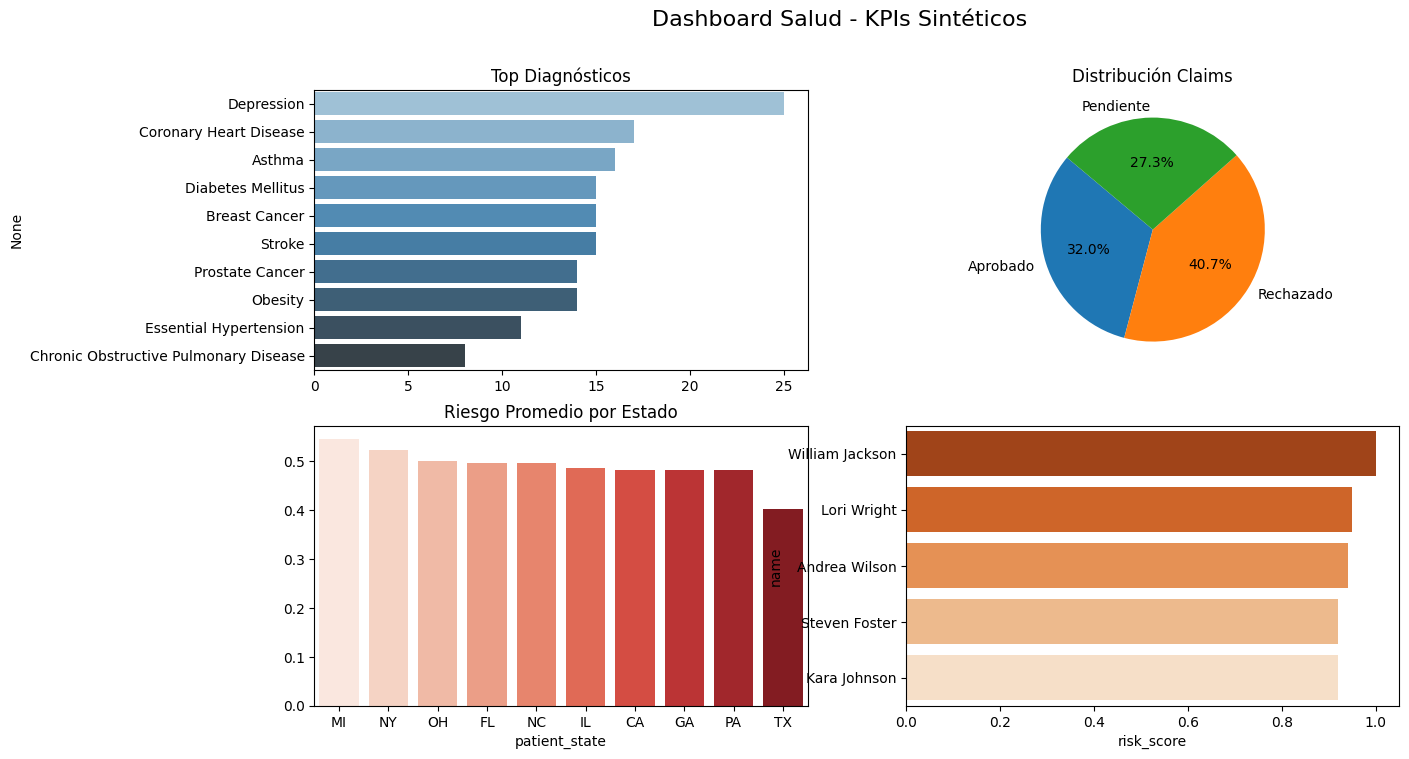

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Verifica el tipo de DataFrame y usa el método correcto:
if "pyspark" in str(type(df_synth)):
    pdf = df_synth.limit(150).toPandas()
else:
    pdf = df_synth.head(150)  # Pandas

# Total de pacientes
total_pacientes = pdf['patient_id'].nunique()
# Distribución de diagnósticos
diag_counts = pdf['diagnosis'].value_counts().head(10)
# Tasa de aprobación de claims
aprobados = (pdf['claim_status'] == 'Approved').sum()
rechazados = (pdf['claim_status'] == 'Rejected').sum()
pendientes = (pdf['claim_status'] == 'Pending').sum()
tasa_aprob = aprobados / (aprobados + rechazados + pendientes)
# Riesgo promedio por estado
riesgo_estado = pdf.groupby('patient_state')['risk_score'].mean().sort_values(ascending=False)
# Top 5 pacientes más alto riesgo
top_riesgo = pdf[['name','risk_score','diagnosis','patient_state']].sort_values('risk_score', ascending=False).head(5)

print(f"Total pacientes: {total_pacientes}")
print(f"Top diagnósticos:\n{diag_counts}")
print(f"Tasa de aprobación claims: {tasa_aprob:.2%}")
print("Riesgo promedio por estado:\n", riesgo_estado)
print("Top 5 pacientes mayor riesgo:\n", top_riesgo)
# --- Visual Dashboard ---
fig, axs = plt.subplots(2,2, figsize=(14,8))
fig.suptitle('Dashboard Salud - KPIs Sintéticos', fontsize=16)
# Diagnósticos
sns.barplot(y=diag_counts.index, x=diag_counts.values, ax=axs[0,0], palette='Blues_d')
axs[0,0].set_title('Top Diagnósticos')
# Claim Status
axs[0,1].pie([aprobados, rechazados, pendientes], labels=['Aprobado','Rechazado','Pendiente'], autopct='%1.1f%%', startangle=140)
axs[0,1].set_title('Distribución Claims')
# Riesgo por estado
sns.barplot(x=riesgo_estado.index, y=riesgo_estado.values, ax=axs[1,0], palette='Reds')
axs[1,0].set_title('Riesgo Promedio por Estado')
# Top riesgo
sns.barplot(y=top_riesgo['name'], x=top_riesgo['risk_score'], ax=axs[1,1], palette='Oranges_r')



In [0]:
# Visualización de tasa de aprobación de claims
display(pdf.groupby('claim_status').size().reset_index(name='conteo'))
# Diagnóstico por estado
display(pdf.groupby(['patient_state','diagnosis']).size().reset_index(name='conteo'))
# Riesgo promedio por estado
display(pdf.groupby('patient_state')['risk_score'].mean().reset_index())


claim_status,conteo
Approved,48
Pending,41
Rejected,61


patient_state,diagnosis,conteo
CA,Asthma,3
CA,Coronary Heart Disease,1
CA,Diabetes Mellitus,2
CA,Obesity,5
CA,Prostate Cancer,1
CA,Stroke,1
FL,Asthma,3
FL,Breast Cancer,2
FL,Coronary Heart Disease,2
FL,Depression,2


patient_state,risk_score
CA,0.48230769230769227
FL,0.49733333333333335
GA,0.4816666666666667
IL,0.4852631578947369
MI,0.545625
NC,0.4963157894736842
NY,0.5223529411764707
OH,0.5
PA,0.4811111111111111
TX,0.403125


# 7. Cierre y próximos pasos

---
## Conclusión

Con este notebook:
- Aprendiste cómo integrar datos reales, sintéticos y contextuales (APIs) en un solo flujo de trabajo.
- Aplicaste los 4 niveles de madurez en IA (prompting, integración, tuning, batch).
- Visualizaste cómo los sistemas enterprise de IA pueden combinar datos, contexto y lógica de negocio para crear valor real.

**¿Qué sigue?**
- Escala los ejemplos a datasets más grandes.
- Prueba APIs externas de tu contexto real.
- Añade visualizaciones y dashboards ejecutivos.
- Conecta tu pipeline a modelos productivos.

¿Listo para transformar tu empresa (o tu portafolio) con IA de verdad?
---
